# Assignment 4 Problem III: Helmholtz Newton CG #

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import dolfin as dl
import ufl

import hippylib as hp
from hippylib import nb

import numpy as np
import logging


logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

np.random.seed(seed=42)

\begin{gather*}
  m(x,y) = \begin{cases}
    0.2 & \text{if} \; \sqrt{(x - 0.1)^2 + 2 (y + 0.2)^2} < 0.5 \\
    0 & \text{otherwise} \\
  \end{cases} \\
\end{gather*}


Refinement level 0; Number of mesh elements: 6402


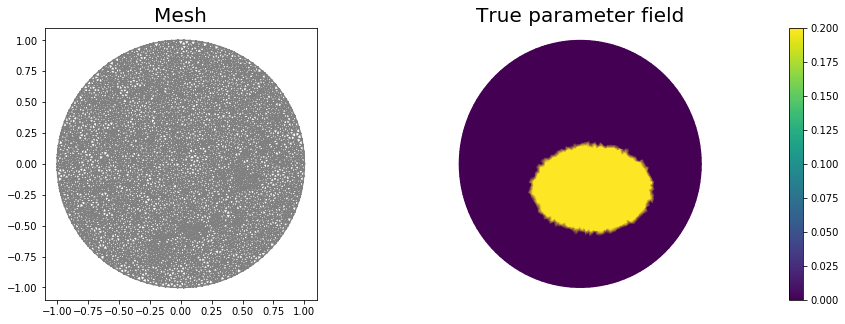

In [2]:
# create mesh and define function spaces
# mesh = dl.RectangleMesh(dl.Point(-1,-1),dl.Point(1,1), 32, 32)
mesh = dl.Mesh("circle.xml")
print("Refinement level 0; Number of mesh elements: {0}".format(mesh.num_cells()))

nrefinements = 0
for i in range(nrefinements):
    mesh = dl.refine(mesh)
    print("Refinement level {0}; Number of mesh elements: {1}".format(i+1, mesh.num_cells()))

Vm = dl.FunctionSpace(mesh, 'Lagrange', 1)
Vu = dl.FunctionSpace(mesh, 'Lagrange', 2)

# The true parameter, continuous and discretized/interpolated.
mtrue_cont = dl.Expression('0. + 0.2 * ((pow(x[0] - 0.1, 2) + 2*pow(x[1] + 0.2, 2)) < pow(0.5,2))', degree=5)
mtrue = dl.interpolate(mtrue_cont, Vm)

# plot
plt.figure(figsize=(15,5))
nb.plot(mesh, subplot_loc=121, mytitle="Mesh", show_axis='on')
nb.plot(mtrue, subplot_loc=122, mytitle="True parameter field")
plt.show()

The computational domain $\Omega = \{ x \in \mathbb{R}^2 \; | \; {\lVert x \rVert}^2 < 1 \}$ is the unit disc, $k_0 = 5$ is the wave number, and $\beta > 0$ is the regularization parameter. The incident wavefield $u^{\text{inc}}(x)$ is the superposition of three spherical waves with wave number $k_0$ generated by point-like sources. That is:

\begin{gather*}
  u^{\text{inc}}(x) = \sum\limits_{j=1}^{3} -e_i \frac{\cos (k_0 {\lvert x - x_i \rvert})}{4 \pi {\lvert x - x_i \rvert}} \\
\end{gather*}

where $x_i$ denote the locations of the three point-like sources and $e_i \sim N(0,1)$ are randomly chosen coefficients.

We will actually define $u_i$ for $\{1,2,3\}$ first, then multiply by the random number and combine in the next step.


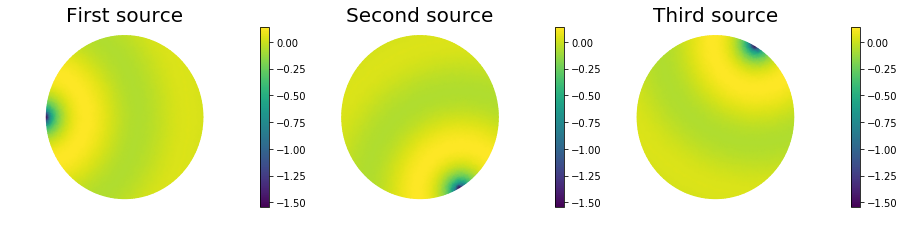

In [3]:
k0raw = 5.
k0sq = dl.Constant(k0raw*k0raw)
nsources = 3

def build_inc_wave(i):
    theta = -np.pi + 2*np.pi*i/nsources
    radius = 1.05
    xi = [radius*np.cos(theta), radius*np.sin(theta)]
    
    ei = np.random.normal()
    
    distance_source = dl.Expression("std::sqrt((x[0]-s0)*(x[0]-s0) + (x[1]-s1)*(x[1]-s1))",
                                    s0=xi[0], s1=xi[1], degree=1)
    u_i_exp = dl.Expression("-std::cos(k0*distance_source)/(4.*DOLFIN_PI*distance_source)",
                              k0=k0raw, distance_source=distance_source, degree=6)
    return dl.interpolate(u_i_exp, Vu)

# build_inc_wave(1)
u_is = [build_inc_wave(i) for i in range(nsources)]

# plot
plt.figure(figsize=(15,3.3))
nb.plot(u_is[0], subplot_loc=131, mytitle="First source")
nb.plot(u_is[1], subplot_loc=132, mytitle="Second source")
nb.plot(u_is[2], subplot_loc=133, mytitle="Third source")
plt.show()

## Source encoding

Source encoding is a common technique based on superposition of effects to reduce the computational cost of full-waveform inversion.

Simply put, source encoding exploits the linearity of the Helmholtz equation with respect to the source term and computes a single pressure field correspoding to the simulataneous exitation of all sources together. Here, we take the superimposed source $u_inc$ to be a random linear combination of all sources $u_i$. The weights $e_i$ of this linear combination are sampled from a i.i.d. Gaussian distribution. That is:

$$ u_{inc}(\boldsymbol{x}) = \sum_i e_i u_i(\boldsymbol{x}), \quad e_i \sim \mathcal{N}(0,1). $$

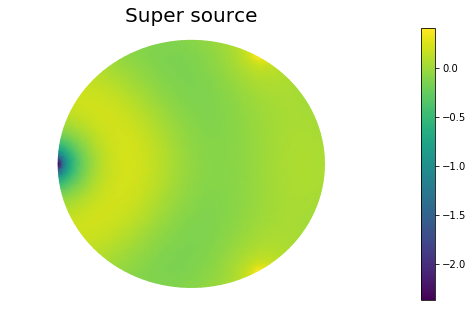

In [4]:
encoding = np.random.normal(size=nsources)

u_inc = dl.Function(Vu)

for i, u_i in enumerate(u_is):
    u_inc.vector().axpy(encoding[i], u_i.vector())
    
plt.figure(figsize=(7.5,5))
nb.plot(u_inc, mytitle="Super source")
plt.show()

In [5]:
# define trial/test/regular functions for parameter, state and adjoint
m, m_trial, m_test = dl.Function(Vm), dl.TrialFunction(Vm), dl.TestFunction(Vm)
u, u_trial, u_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)
p, p_trial, p_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)


The forward equation is the Helmholtz equation:

\begin{gather*}
  - \Delta u - k_0^2 (1 - \tanh(m)) u = k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}}, \quad \text{in} \; \Omega \\
  \frac{\partial u}{\partial n} = 0, \quad \text{on} \; \Gamma \\
\end{gather*}


in weak form:

\begin{gather*}
%  - \int_\Omega \Delta u p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^\text{inc} p \; d\vec{x} \\
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


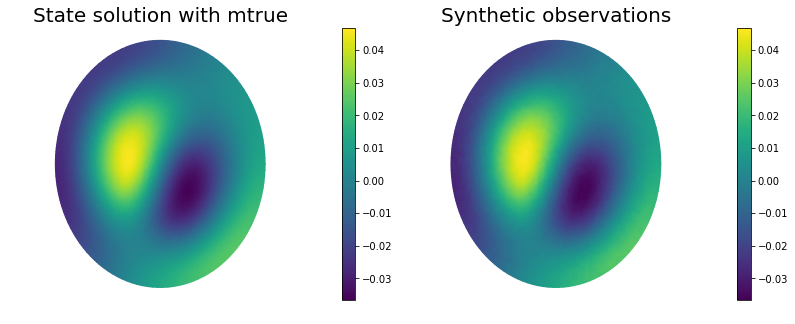

In [6]:
# noise level
noise_level = 0.01

forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(mtrue)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(mtrue) * u_inc * u_test * ufl.dx

# solve the forward/state problem to generate synthetic observations
bc_state = []
forward_lhsa, forward_rhsa = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)

utrue = dl.Function(Vu)
dl.solve(forward_lhsa, utrue.vector(), forward_rhsa)
assert np.all(np.isfinite(utrue.vector().get_local())), "State solution contains NaNs"


d = dl.Function(Vu)
d.assign(utrue)

# perturb state solution and create synthetic measurements d
# d = u + ||u||/SNR * random.normal
MAX = d.vector().norm("linf")
noise = dl.Vector()
forward_lhsa.init_vector(noise,1)
noise.set_local( noise_level * MAX * np.random.normal(0, 1, len(d.vector().get_local())) )

d.vector().axpy(1., noise)

# plot
nb.multi1_plot([utrue, d], ["State solution with mtrue", "Synthetic observations"])
plt.show()

Our cost function is as follows:

\begin{gather*}
  \min\limits_{m} \Phi (m) := \frac{1}{2}
  \int_\Gamma (u(m) - d)^2 \; ds
  + \frac{\beta}{2} \int_\Omega {\lVert \nabla m \rVert}^2 \; d\vec{x} \\
\end{gather*}


In [7]:
# Regularization parameter
gamma = 1e-5
beta = gamma

# Define cost function
def cost(u, d, m, gamma):
    misfit = 0.5 * dl.assemble( (u-d)**2*ufl.ds)
    reg = 0.5*gamma * dl.assemble( ufl.inner(dl.grad(m), ufl.grad(m))*ufl.dx ) 
    return [misfit + reg, misfit, reg]

Our forward equation in weak form. We covered this earlier, but we are redefining with $m$ instead of $m_{\text{true}}$

\begin{gather*}
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


In [8]:
# We defined this earlier, but now we define with variable m, not m_true.
# Given m, solve for u.
forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(m)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(m) * u_inc * u_test * ufl.dx

# set up dirichlet boundary conditions
def boundary(x,on_boundary):
    return on_boundary

bc_state = [] # dl.DirichletBC(Vu, dl.Constant(0.), boundary)

The first variation of the Lagrangian with respect to $u$ gives us the weak form of the adjoint equation:

\begin{gather*}
  \mathcal{L}_u(u,m,p; \tilde{u}) :=
  \int_\Gamma (u - d) \tilde{u} \; d\vec{s}
  + \int_\Omega \nabla \tilde{u} \nabla p
  - k_0^2 (1 - \tanh(m)) \tilde{u} p
  \; d\vec{x}, \quad \forall \tilde{u} \in \mathcal{V} \\
\end{gather*}

In [ ]:
# Given m, u, solve for adjoint p
# adjoint_eq = ufl.inner(u-d, p_test) * ufl.ds \
#     + ufl.inner(ufl.grad(p_test), ufl.grad(p_trial)) * ufl.dx \
#     - k0sq * (1. - ufl.tanh(m)) * p_test * p_trial * ufl.dx
adjoint_eq = (u - d) * p_test * ufl.ds \
   + ufl.inner(ufl.grad(p_trial), ufl.grad(p_test)) * ufl.dx \
   - k0sq * (1. - ufl.tanh(m)) * p_trial * p_test * ufl.dx


bc_adj = [] # The first term is the boundary condition.

The first variation of the Lagrangian with respect to $m$ gives us the weak form of the gradient of the objective when we use the corresponding $u,p$ from the state equation and adjoint equation:

\begin{gather*}
  \mathcal{L}_m(u,m,p; \tilde{m}) :=
  \int_\Omega \beta \nabla m \nabla \tilde{m} \; d\vec{x}
  + \int_\Omega k_0^2 \cdot \tilde{m} / \cosh^2(m) \cdot (u p - u^{\text{inc}} p) \; d\vec{x}
  , \quad \forall \tilde{m} \in \mathcal{M} \\
\end{gather*}

In [ ]:
# Given m, u, p, solve for adjoint p
grad_reg = dl.Constant(gamma) * ufl.inner(ufl.grad(m), ufl.grad(m_test)) * ufl.dx
grad_misfit = k0sq * m_test / (ufl.cosh(m) * ufl.cosh(m)) * (u * p - u_inc * p) * ufl.dx


### Finite difference check of the gradient

We use a **finite difference check** to verify that our gradient derivation is correct.
Specifically, we consider a function $ m_0\in \mathcal{M}$ and we verify that for an arbitrary direction $\tilde{m} \in \mathcal{M}$ we have
$$ r := \left| \frac{ \mathcal{J}(m_0 + \varepsilon \tilde{m}) - \mathcal{J}(m_0)}{\varepsilon} -  \left(\mathcal{G}(m_0), \tilde{m}\right)\right| = \mathcal{O}(\varepsilon).$$

In the figure below we show in a loglog scale the value of $r$ as a function of $\varepsilon$. We observe that $r$ decays linearly for a wide range of values of $\varepsilon$, however we notice an increase in the error for extremely small values of $\varepsilon$ due to numerical stability and finite precision arithmetic.


State norm: 0.0
c0=0.0010527675252309317
Adjoint norm: 1.2431027232062508
grad0 norm: 0.002366969441128815


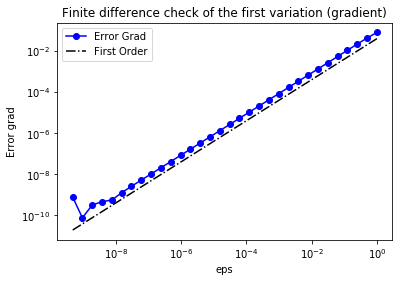

In [ ]:
# Poisson m0
# m0 = dl.interpolate(dl.Constant(np.log(4.) ), Vm )
# Helmholtz m0
m0 = dl.interpolate(dl.Constant( 0. ), Vm )

n_eps = 32
eps = np.power(2., -np.arange(n_eps))
err_grad = np.zeros(n_eps)

m.assign(m0)

# Solve the fwd problem and evaluate the cost functional
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
print("State norm:", u.vector().norm("l2"))    

c0, _, _ = cost(u, d, m, gamma)
print(f"c0={c0}")

# Solve the adjoint problem and evaluate the gradient
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"
print("Adjoint norm:", p.vector().norm("l2"))    

# evaluate the gradient
grad0 = dl.assemble(grad_misfit + grad_reg)
print("grad0 norm:", grad0.norm("l2"))    

# Define an arbitrary direction m_hat to perform the check 
mtilde = dl.Function(Vm).vector()
mtilde.set_local(np.random.randn(Vm.dim()))
mtilde.apply("")
mtilde_grad0 = grad0.inner(mtilde)

for i in range(n_eps):
    m.assign(m0)
    m.vector().axpy(eps[i], mtilde)
    
    A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
    dl.solve(A, u.vector(), state_b)
    assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
#     print("State norm:", u.vector().norm("l2"))

    cplus, _, _ = cost(u, d, m, gamma)
   
    err_grad[i] = abs( (cplus - c0)/eps[i] - mtilde_grad0 )

plt.figure()    
plt.loglog(eps, err_grad, "-ob", label="Error Grad")
plt.loglog(eps, (.5*err_grad[0]/eps[0])*eps, "-.k", label="First Order")
plt.title("Finite difference check of the first variation (gradient)")
plt.xlabel("eps")
plt.ylabel("Error grad")
plt.legend(loc = "upper left")
plt.show()

### Initial guess

We solve the state equation and compute the cost functional for the initial guess of the parameter ``m0``

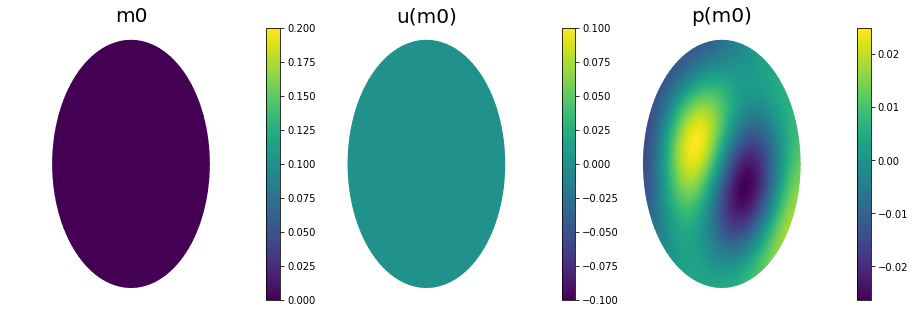

In [ ]:
m.assign(m0)

# solve state equation
state_A, state_b = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(state_A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

# solve the adoint problem
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "Adjoint solution contains NaNs"


# evaluate cost
[cost_old, misfit_old, reg_old] = cost(u, d, m, gamma)

# plot
plt.figure(figsize=(15,5))
nb.plot(m, subplot_loc=131, mytitle="m0", vmin=mtrue.vector().min(), vmax=mtrue.vector().max())
nb.plot(u, subplot_loc=132, mytitle="u(m0)")
nb.plot(p, subplot_loc=133, mytitle="p(m0)")
plt.show()

In [ ]:
# L^2 weighted inner product
M_varf   = ufl.inner(m_trial, m_test) * ufl.dx
M = dl.assemble(M_varf)

### Variational forms for Hessian action

We define the following variational forms that are needed for the Hessian evaluation

- `W_varf`, `R_varf` are the second variation of the data-misfit and regularization component of the cost functional respectively (note since `W_varf`, `R_varf` are independent of $u$, $m$, $p$ they can be preassembled);

- `C_varf` is the second variation of the PDE with respect to $p$ and $m$;

- `Wum_varf` is the second variation of the PDE with respect to $u$ and $m$;

- `Wmm_varf` is the second variation of the PDE with respect to $m$.

> **Note**: Since the forward problem is linear, the bilinear forms for the incremental state and adjoint equations are the same as the bilinear forms for the state and adjoint equations, respectively.

In [ ]:
W_varf   = ufl.inner(u_trial, u_test) * ufl.dx
R_varf   = dl.Constant(gamma) * ufl.inner(ufl.grad(m_trial), ufl.grad(m_test)) * ufl.dx

C_varf   = ufl.inner(ufl.exp(m) * m_trial * ufl.grad(u), ufl.grad(u_test)) * ufl.dx
Wum_varf = ufl.inner(ufl.exp(m) * m_trial * ufl.grad(p_test), ufl.grad(p)) * ufl.dx
Wmm_varf = ufl.inner(ufl.exp(m) * m_trial * m_test *  ufl.grad(u),  ufl.grad(p)) * ufl.dx

# Assemble constant matrices
W = dl.assemble(W_varf)
R = dl.assemble(R_varf)

### 8. Hessian action on a vector $\bhm$:

Here we describe how to apply the Hessian operator to a vector $\bhm$. For an opportune choice of the regularization, the Hessian operator evaluated in a neighborhood of the solution is positive define, whereas far from the solution the reduced Hessian may be indefinite. On the constrary, the Gauss-Newton approximation of the Hessian is always positive defined.

For this reason, it is beneficial to perform a few initial Gauss-Newton steps (5 in this particular example) to accelerate the convergence of the inexact Newton-CG algorithm.

The Hessian action reads:
$$
\begin{align}
\bhu &= -\bA^{-1} \bC \bhm\, & \text{incremental forward}\\
\bhp &= -\bA^{-T} (\bW_{\scriptsize\mbox{uu}} \bhu +
\bW_{\scriptsize\mbox{um}}\,\bhm) & \text{incremental adjoint}\\
\bH \bhm &= (\bR + \bW_{\scriptsize\mbox{mm}})\bhm + \bC^T \bhp + \bW_{\scriptsize\mbox{mu}} \bhu.
\end{align}
$$

The Gauss-Newton Hessian action is obtained by dropping the second derivatives operators $\bW_{\scriptsize\mbox{um}}\,\bhm$, $\bW_{\scriptsize\mbox{mm}}\bf \bhm$, and $\bW_{\scriptsize\mbox{mu}} \bhu$:
$$
\begin{align}
\bhu &= -\bA^{-1} \bC \bf \bhm\, & \text{incremental forward}\\
\bhp &= -\bA^{-T} \bW_{\scriptsize\mbox{uu}} \bhu & \text{incremental adjoint}\\
\bH_{\rm GN} \bhm &= \bR \bhm + \bC^T \bhp.
\end{align}
$$



In [ ]:
# Class HessianOperator to perform Hessian apply to a vector
class HessianOperator():
    cgiter = 0
    def __init__(self, R, Wmm, C, A, adj_A, W, Wum, bc0, use_gaussnewton=False):
        self.R = R
        self.Wmm = Wmm
        self.C = C
        self.A = A
        self.adj_A = adj_A
        self.W = W
        self.Wum = Wum
        self.bc0 = bc0
        self.use_gaussnewton = use_gaussnewton
        
        # incremental state
        self.du = dl.Vector()
        self.A.init_vector(self.du,0)
        
        #incremental adjoint
        self.dp = dl.Vector()
        self.adj_A.init_vector(self.dp,0)
        
        # auxiliary vector
        self.Wum_du = dl.Vector()
        self.Wum.init_vector(self.Wum_du, 1)
        
    def init_vector(self, v, dim):
        self.R.init_vector(v,dim)

    # Hessian performed on v, output as generic vector y
    def mult(self, v, y):
        self.cgiter += 1
        y.zero()
        if self.use_gaussnewton:
            self.mult_GaussNewton(v,y)
        else:
            self.mult_Newton(v,y)
            
    # define (Gauss-Newton) Hessian apply H * v
    def mult_GaussNewton(self, v, y):
        
        #incremental forward
        rhs = -(self.C * v)
        for bc in self.bc0:
            bc.apply(rhs)
        dl.solve (self.A, self.du, rhs)
        
        #incremental adjoint
        rhs = - (self.W * self.du)
        for bc in self.bc0:
            bc.apply(rhs)
        dl.solve (self.adj_A, self.dp, rhs)
                
        # Misfit term
        self.C.transpmult(self.dp, y)
        
        if self.R:
            Rv = self.R*v
            y.axpy(1, Rv)
        
    # define (Newton) Hessian apply H * v
    def mult_Newton(self, v, y):
        
        #incremental forward
        rhs = -(self.C * v)
        for bc in self.bc0:
            bc.apply(rhs)
        dl.solve (self.A, self.du, rhs)
        
        #incremental adjoint
        rhs = -(self.W * self.du) -  self.Wum * v
        for bc in self.bc0:
            bc.apply(rhs)
        dl.solve (self.adj_A, self.dp, rhs)
                
        #Misfit term
        self.C.transpmult(self.dp, y)
        
        self.Wum.transpmult(self.du, self.Wum_du)
        y.axpy(1., self.Wum_du)
        
        y.axpy(1., self.Wmm*v)
        
        #Reg/Prior term
        if self.R:
            y.axpy(1., self.R*v)
        

### 9. The inexact Newton-CG optimization with Armijo line search:

We solve the constrained optimization problem using the inexact Newton-CG method with Armijo line search.

The stopping criterion is based on a relative reduction of the norm of the gradient (i.e. $\frac{\|g_{n}\|}{\|g_{0}\|} \leq \tau$).

First, we compute the gradient by solving the state and adjoint equation for the current parameter $m$, and then substituing the current state $u$, parameter $m$ and adjoint $p$ variables in the weak form expression of the gradient:
$$ (\mathcal{G}(m), \tilde{m}) = \gamma\int_\Omega \nabla m \cdot \nabla \tilde{m} dx +\int_\Omega \tilde{m}\nabla u \cdot \nabla p\, dx.$$

Then, we compute the Newton direction $\hat m$ by iteratively solving $\mathcal{H} {\hat m} = -\mathcal{G}$.
The Newton system is solved inexactly by early termination of conjugate gradient iterations via Eisenstat–Walker (to prevent oversolving) and Steihaug  (to avoid negative curvature) criteria. 

> Usually, one uses the regularization matrix $R$ as preconditioner for the Hessian system, however since $R$ is singular (the constant vector is in the null space of $R$), here we use $P = R + \frac{\gamma}{10} M$, where $M$ is the mass matrix in parameter space.

Finally, the Armijo line search uses backtracking to find $\alpha$ such that a sufficient reduction in the cost functional is achieved.
More specifically, we use backtracking to find $\alpha$ such that:
$$J( m + \alpha \hat m ) \leq J(m) + \alpha c_{\rm armijo} (\hat m,g). $$

In [ ]:
# define parameters for the optimization
tol = 1e-8
c = 1e-4
maxiter = 50
plot_on = False

# initialize iter counters
iter = 1
total_cg_iter = 0
converged = False

# initializations
g, m_delta = dl.Vector(), dl.Vector()
R.init_vector(m_delta,0)
R.init_vector(g,0)

m_prev = dl.Function(Vm)

print( "Nit   CGit   cost          misfit        reg           sqrt(-G*D)    ||grad||       alpha  tolcg" )

while iter <  maxiter and not converged:

    # solve the adoint problem
    adjoint_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
    dl.solve(adjoint_A, p.vector(), adjoint_RHS)
    assert np.all(np.isfinite(p.vector().get_local())), "Adjoint solution contains NaNs"
    print("Adjoint norm:", p.vector().norm("l2"))    

    # evaluate the  gradient
    MG = dl.assemble(grad_misfit + grad_reg)

    # calculate the L^2 norm of the gradient
    dl.solve(M, g, MG)
    grad2 = g.inner(MG)
    gradnorm = np.sqrt(grad2)

    # set the CG tolerance (use Eisenstat–Walker termination criterion)
    if iter == 1:
        gradnorm_ini = gradnorm
    tolcg = min(0.5, np.sqrt(gradnorm/gradnorm_ini))
    
    # assemble W_um and W_mm
    C   = dl.assemble(C_varf)
    Wum = dl.assemble(Wum_varf)
    Wmm = dl.assemble(Wmm_varf)

    # define the Hessian apply operator (with preconditioner)
    Hess_Apply = HessianOperator(R, Wmm, C, state_A, adjoint_A, W, Wum, bc_adj, use_gaussnewton=(iter<6) )
    P = R + 0.1*gamma * M
    Psolver = dl.PETScKrylovSolver("cg", hp.amg_method())
    Psolver.set_operator(P)
    
    solver = hp.CGSolverSteihaug()
    solver.set_operator(Hess_Apply)
    solver.set_preconditioner(Psolver)
    solver.parameters["rel_tolerance"] = tolcg
    solver.parameters["zero_initial_guess"] = True
    solver.parameters["print_level"] = -1

    # solve the Newton system H a_delta = - MG
    solver.solve(m_delta, -MG)
    total_cg_iter += Hess_Apply.cgiter
    
    # linesearch
    alpha = 1
    descent = 0
    no_backtrack = 0
    m_prev.assign(m)
    while descent == 0 and no_backtrack < 10:
        m.vector().axpy(alpha, m_delta )

        # solve the state/forward problem
        state_A, state_b = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
        dl.solve(state_A, u.vector(), state_b)
        assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

        # evaluate cost
        [cost_new, misfit_new, reg_new] = cost(u, d, m, gamma)

        # check if Armijo conditions are satisfied
        if cost_new < cost_old + alpha * c * MG.inner(m_delta):
            cost_old = cost_new
            descent = 1
        else:
            no_backtrack += 1
            alpha *= 0.5
            m.assign(m_prev)  # reset a

    # calculate sqrt(-G * D)
    graddir = np.sqrt(- MG.inner(m_delta) )

    sp = ""
    print( "%2d %2s %2d %3s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %5.2f %1s %5.3e" % \
        (iter, sp, Hess_Apply.cgiter, sp, cost_new, sp, misfit_new, sp, reg_new, sp, \
         graddir, sp, gradnorm, sp, alpha, sp, tolcg) )

    if plot_on:
        nb.multi1_plot([m,u,p], ["m","u","p"], same_colorbar=False)
        plt.show()
    
    # check for convergence
    if gradnorm < tol and iter > 1:
        converged = True
        print( "Newton's method converged in ",iter,"  iterations" )
        print( "Total number of CG iterations: ", total_cg_iter )
        
    iter += 1
    
if not converged:
    print( "Newton's method did not converge in ", maxiter, " iterations" )

Nit   CGit   cost          misfit        reg           sqrt(-G*D)    ||grad||       alpha  tolcg
Adjoint norm: 1.2431027232062508
 1     4     1.43341e+22   1.43341e+22   1.99785e+07   3.23632e+06   7.75537e-02    0.00   5.000e-01
Adjoint norm: 1738692640385.6553
 2     1     9.96541e+33   9.65996e-01   9.96541e+33   7.72487e+22   4.60196e+22    0.00   5.000e-01
Adjoint norm: 16.593809631592226
 3     1     1.43341e+22   1.43341e+22   5.13379e-02   1.10943e+03   3.25071e+00    0.00   5.000e-01
Adjoint norm: 1738692640385.6553
 4     1     9.96541e+33   9.65996e-01   9.96541e+33   7.72487e+22   4.60196e+22    0.00   5.000e-01
Adjoint norm: 16.593809631592226
 5     1     1.43341e+22   1.43341e+22   5.13379e-02   1.10943e+03   3.25071e+00    0.00   5.000e-01
Adjoint norm: 1738692640385.6553
 6    1000     3.62909e+21   9.65996e-01   3.62909e+21   2.14036e+19   4.60196e+22    0.00   5.000e-01
Adjoint norm: 16.593809631592226
 7     1     1.43341e+22   1.43341e+22   5.13379e-02   1.10943e+

In [ ]:
# plot
plt.figure(figsize=(15,5))
nb.plot(mtrue, subplot_loc=121, mytitle="True parameter field")
nb.plot(m, subplot_loc=122, mytitle="Solved parameter field")
plt.show()

In [ ]:
# plot
plt.figure(figsize=(15,5))
nb.plot(utrue, subplot_loc=121, mytitle="u(mtrue)")
nb.plot(u, subplot_loc=122, mytitle="u(m)")
plt.show()